# execute tex before on-chain

In [1]:
import os

import brotli
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import time

from tqdm import tqdm

from tex_tool import TexExtractor, RSAKeyManager, AESKeyManager

In [2]:
BROTLI_QUALITY = 11
BASE_DIR = "files"
INPUT_XLSX = f"{BASE_DIR}/arxiv_tex_dataset.xlsx"
OUTPUT_XLSX = f"{BASE_DIR}/hex.xlsx"
TAR_DIR = f"{BASE_DIR}/downloads/"
HEX_DIR = f"{BASE_DIR}/hexs/"

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

In [4]:
rsamanager = RSAKeyManager()
try:
    rsamanager.load_private_key()
except Exception:
    rsamanager.generate_private_key()
    rsamanager.save_private_key()
    rsamanager.generate_public_key()
    rsamanager.save_public_key()

加载私钥失败: [Errno 2] No such file or directory: 'files/private_key.pem'


In [6]:
pd.read_excel(INPUT_XLSX)

,id,title,year,tex_size_clean
0,2604.15279v1,Wave-Based Dispatch for Circuit Cutting in Hyb...,2026,101876
1,2604.15186v1,Scepsy: Serving Agentic Workflows Using Aggreg...,2026,70634
2,2604.15128v1,SCENIC: Stream Computation-Enhanced SmartNIC,2026,59791
3,2604.15039v1,Prefill-as-a-Service: KVCache of Next-Generati...,2026,59932
4,2604.15033v1,Efficient calculation of available space for m...,2026,45810
...,...,...,...,...
467,2603.02603v1,Why Atomicity Matters to AI/ML Infrastructure:...,2026,55090
468,2603.02597v1,GPUTOK: GPU Accelerated Byte Level BPE Tokeniz...,2026,38575
469,2603.02510v1,ParEVO: Synthesizing Code for Irregular Data: ...,2026,109936
470,2603.02376v1,CUCo: An Agentic Framework for Compute and Com...,2026,73455


In [ ]:
def main():
    df = pd.read_excel(INPUT_XLSX)

    results = []
    total = len(df)
    pbar = tqdm(df.iterrows(), total=total, desc="Processing papers")
    aesmanager = AESKeyManager()
    rsamanager = RSAKeyManager()
    rsamanager.load_public_key()
    rsamanager.load_private_key()
    for idx, row in pbar:
        arxiv_id = row["id"]
        tar_path = os.path.join(TAR_DIR, f"{arxiv_id}.tar.gz")

        pbar.set_postfix({
            "index": f"{idx+1}/{total}",
            "id": arxiv_id
        })

        if not os.path.exists(tar_path):
            continue

        extractor = TexExtractor(tar_path)
        text = extractor.get_merged_tex()

        b = text.encode("utf-8", errors="ignore")
        original_size = len(b)

        if original_size == 0:
            continue

        compressed = brotli.compress(b, quality=BROTLI_QUALITY)
        
        start = time.perf_counter()
        encrypted_key = rsamanager.encrypt(aesmanager.generate_key())
        key_encrypt_time = time.perf_counter()- start
        start = time.perf_counter()
        encrypted = aesmanager.encrypt(compressed)
        text_encrypt_time = time.perf_counter()- start
        zero_count = encrypted.count(0)
        h = encrypted.hex()

        start = time.perf_counter()
        incipient_key = rsamanager.decrypt(encrypted_key)
        key_decrypt_time = time.perf_counter()- start
        start = time.perf_counter()
        incipient_text = AESKeyManager(incipient_key).decrypt(encrypted)
        text_decrypt_time = time.perf_counter()- start

        if incipient_text != compressed:
            print(f'fail, {arxiv_id}')

        ## save hex
        os.makedirs(HEX_DIR, exist_ok=True)
        json_path = os.path.join(HEX_DIR, f"{arxiv_id}.json")

        with open(json_path, "w") as f:
            json.dump({
                "id": arxiv_id,
                "title": row["title"],
                "author": [],
                "tar": f"files/downloads/{arxiv_id}.tar.gz",
                "extraMetadataURI": f"https://arxiv.org/abs/{arxiv_id}",
                "key": encrypted_key.hex(),
                "data": h
            }, f)

        results.append({
            "id": arxiv_id,
            "title": row['title'],
            "original_size": original_size,
            "compressed_size": len(compressed),
            "encrypted_size": len(encrypted),
            "zerobytes": zero_count,
            "key_encrypt_time": key_encrypt_time,
            "key_decrypt_time": key_decrypt_time,
            "text_encrypt_time": text_encrypt_time,
            "text_decrypt_time": text_decrypt_time
        })


    result_df = pd.DataFrame(results)
    result_df.to_excel(OUTPUT_XLSX, index=False)

    print("Done! Results saved to:", OUTPUT_XLSX)

In [11]:
main()

Processing papers: 100%|██████████| 378/378 [00:31<00:00, 11.97it/s, index=378/378, id=2602.10444v1]


Done! Results saved to: files/hex.xlsx


In [3]:
def get_df(f:str):
    df = pd.read_excel(f)
    return df
original_df = get_df(OUTPUT_XLSX)

# distribution

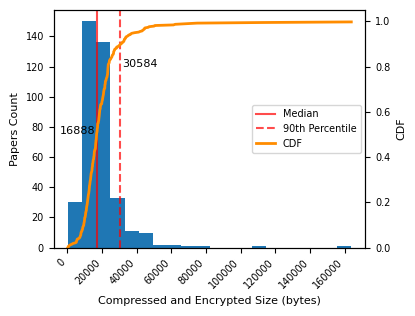

In [4]:

def combined_plot(df):
    sizes = df["encrypted_size"]
    sorted_sizes = np.sort(sizes)
    cdf = np.arange(len(sorted_sizes)) / len(sorted_sizes)
    
    # 创建图形和主坐标轴
    fig, ax1 = plt.subplots(figsize=(4.2, 3.2))
    
    # 左y轴：直方图
    n, bins, patches = ax1.hist(sizes, bins=20)
    ax1.set_xlabel("Compressed and Encrypted Size (bytes)")
    ax1.set_ylabel("Papers Count")
    ax1.tick_params(axis='y')
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 右y轴：CDF
    ax2 = ax1.twinx()
    ax2.plot(sorted_sizes, cdf, color='darkorange', linewidth=2, label='CDF')
    ax2.set_ylabel("CDF")
    ax2.tick_params(axis='y')
    ax2.set_ylim(0, 1.05)
    
    # 添加中位数和90%分位数
    median = np.median(sizes)
    p90 = np.percentile(sizes, 90)
    
    # 在直方图区域添加竖线
    ax1.axvline(median, linestyle='-', label='Median', color='red', alpha=0.7)
    ax1.axvline(p90, linestyle='--', label='90th Percentile', color='red', alpha=0.7)
    
    # 添加文本标注（调整位置避免重叠）
    ax1.text(median-21000, max(n)*0.5, f"{median:.0f}")
    ax1.text(p90+1000, max(n)*0.8, f"{p90:.0f}")
    
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.tight_layout()
    plt.show()
combined_plot(original_df)

In [6]:
def get_median(df, target):
    closest_idx = (df['encrypted_size'] - target).abs().idxmin()
    return df.loc[closest_idx]
get_median(original_df, 16888)

id                                                        2602.22017v2
title                IOAgent: Democratizing Trustworthy HPC I/O Per...
original_size                                                    60928
compressed_size                                                  16854
encrypted_size                                                   16880
key_encrypt_time                                              0.000111
key_decrypt_time                                               0.00046
text_encrypt_time                                             0.000105
text_decrypt_time                                             0.000034
Name: 260, dtype: object

In [54]:
def get_max(df):
    closest_idx = (df['encrypted_size']).idxmax()
    return df.loc[closest_idx]
get_max(original_df)

id                                                        2603.25100v1
title                From Logic Monopoly to Social Contract: Separa...
original_size                                                   693025
compressed_size                                                 163799
encrypted_size                                                  163824
key_encrypt_time                                              0.000199
key_decrypt_time                                              0.000513
text_encrypt_time                                             0.000265
text_decrypt_time                                             0.000092
zerobytes                                                          662
Name: 20, dtype: object

## zero bytes

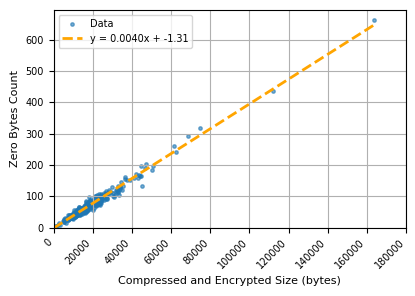

Linear model: y = 0.003964x + -1.31


In [5]:
def zerobytes(df):

    x = df["encrypted_size"].values
    y = df["zerobytes"].values

    # =========================
    # 1️⃣ 线性拟合 y = ax + b
    # =========================
    a, b = np.polyfit(x, y, 1)

    # 生成拟合线（从0开始，避免负数）
    x_line = np.linspace(0, x.max(), 100)
    y_line = a * x_line + b

    # =========================
    # 2️⃣ 画图
    # =========================
    fig, ax = plt.subplots(figsize=(4.2, 3))

    # 散点
    ax.scatter(
        x,
        y,
        s=6,
        alpha=0.6,
        label="Data"
    )

    # 拟合线（换颜色+加粗，避免和点混在一起）
    ax.plot(
        x_line,
        y_line,
        linewidth=2,
        linestyle="--",
        c="orange",
        label=f"y = {a:.4f}x + {b:.2f}"
    )

    # =========================
    # 3️⃣ 坐标轴优化
    # =========================
    ax.set_xlim(left=0)   # 🔥 强制从0开始
    ax.set_ylim(bottom=0)

    ax.set_xlabel("Compressed and Encrypted Size (bytes)")
    ax.set_ylabel("Zero Bytes Count")
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # 打印方程（方便你写论文）
    print(f"Linear model: y = {a:.6f}x + {b:.2f}")
zerobytes(original_df)